# LevHAR Model on the MHAR Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the LevHAR model on the $\mathcal{M}_{\mathrm{HAR}}$ feature set for the EURO STOXX 50 index. Following the same benchmark workflow as the HAR and LogHAR notebooks, we estimate the model on a rolling window and evaluate one-day-ahead forecasts using the Mean Squared Error (MSE). The model is estimated in realized-variance levels using the MHAR predictors together with daily, weekly, and monthly negative-return leverage terms `RD_neg`, `RW_neg`, and `RM_neg`, and all reported results are kept in levels format for direct comparison with the other benchmark models.


## 1.1 Loading Data


In [1]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000078,0.000093,0.000129,-9.462355,-9.288024,-8.958306,0.000046,0.000032,0.000000,-0.000682,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000058,-9.760055
1999-01-06,0.000058,0.000092,0.000123,-9.760055,-9.290171,-9.005038,0.000043,0.000014,0.000000,-0.000682,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000139,-8.877543
1999-01-07,0.000139,0.000102,0.000121,-8.877543,-9.192627,-9.023153,0.000072,0.000068,-0.015530,-0.003788,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000108,-9.130603
1999-01-08,0.000108,0.000106,0.000112,-9.130603,-9.148418,-9.097084,0.000055,0.000053,-0.003409,-0.003788,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000166,-8.702667
1999-01-11,0.000166,0.000110,0.000110,-8.702667,-9.116188,-9.115384,0.000076,0.000090,-0.019561,-0.007700,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000115,-9.067553


## 2. Data Split


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%) in chronological order. The rolling estimation window used for out-of-sample forecasting is the combined training and validation sample, matching the HAR benchmark notebook.


In [2]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. LevHAR Model


The LevHAR benchmark augments the baseline HAR specification with leverage terms across daily, weekly, and monthly horizons:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}^{(w)}_t + \beta_m \overline{RV}^{(m)}_t + \gamma_d RD^{-}_t + \gamma_w RW^{-}_t + \gamma_m RM^{-}_t + \varepsilon_{t+1}$$

where `RD_neg`, `RW_neg`, and `RM_neg` capture the negative daily, weekly, and monthly return aggregates available at time $t$, while `RVD`, `RVW`, and `RVM` retain the standard daily, weekly, and monthly realized variance structure.


### 3.2 Feature Set Construction


In [3]:
# Define target and feature set for LevHAR on MHAR
y = MALL["RV_target"]
X_MHAR = MALL[["RVD", "RVW", "RVM", "RD_neg", "RW_neg", "RM_neg"]]

print("Target variable: RV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())


Target variable: RV_target
Predictors: ['RVD', 'RVW', 'RVM', 'RD_neg']

First few rows:
            RV_target       RVD       RVW       RVM    RD_neg
Date                                                         
1999-01-05   0.000058  0.000078  0.000093  0.000129  0.000000
1999-01-06   0.000139  0.000058  0.000092  0.000123  0.000000
1999-01-07   0.000108  0.000139  0.000102  0.000121 -0.015530
1999-01-08   0.000166  0.000108  0.000106  0.000112 -0.003409
1999-01-11   0.000115  0.000166  0.000110  0.000110 -0.019561


### 3.3 Rolling Window Estimation and Forecasting


In [4]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_LevHAR = []
dates_test = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values

    # OLS estimation in levels
    model = LinearRegression()
    model.fit(X_window, y_window)

    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast = model.predict(X_forecast)[0]

    # Insanity filter: replace negative forecasts with minimum in-sample RV
    min_rv = y_window.min()
    forecast = max(forecast, min_rv)

    forecasts_LevHAR.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_LevHAR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")


Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation


Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using the Mean Squared Error (MSE). LevHAR forecasts and realized values are both compared in realized-variance levels so that the output remains directly comparable to HAR and LogHAR.


In [5]:
# Collect results
results_LevHAR = pd.DataFrame({
    "RV_actual": y.loc[dates_test].values,
    "RV_forecast": forecasts_LevHAR
}, index=dates_test)

# Compute out-of-sample MSE
mse_LevHAR = np.mean((results_LevHAR["RV_actual"] - results_LevHAR["RV_forecast"])**2)

print(f"Out-of-sample MSE (LevHAR): {mse_LevHAR:.6e}")
print(f"\nFirst few forecasts vs actuals:")
print(results_LevHAR.head(10).to_string())


Out-of-sample MSE (LevHAR): 2.241081e-08

First few forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-21   0.000068     0.000113
2016-04-22   0.000079     0.000119
2016-04-25   0.000080     0.000108
2016-04-26   0.000045     0.000083
2016-04-27   0.000157     0.000069
2016-04-28   0.000219     0.000112
2016-04-29   0.000087     0.000252
2016-05-02   0.000107     0.000102
2016-05-03   0.000109     0.000175
2016-05-04   0.000100     0.000169


### 3.4.1 Save Forecasts


In [6]:
import os

# Save LevHAR forecasts to CSV for comparison with other models
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

# Save forecasts
results_LevHAR.to_csv(os.path.join(forecast_path, "forecasts_LevHAR.csv"))

# Save MSE summary
mse_summary_LevHAR = pd.DataFrame({
    "Model": ["LevHAR"],
    "MSE":   [mse_LevHAR],
    "RMSE":  [np.sqrt(mse_LevHAR)],
    "MAE":   [np.mean(np.abs(results_LevHAR["RV_actual"] - results_LevHAR["RV_forecast"]))],
    "Mean_Error": [np.mean(results_LevHAR["RV_actual"] - results_LevHAR["RV_forecast"])],
}).set_index("Model")

mse_summary_LevHAR.to_csv(os.path.join(forecast_path, "mse_summary_LevHAR.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Files saved:")
print(f"  - forecasts_LevHAR.csv ({len(results_LevHAR)} rows)")
print(f"  - mse_summary_LevHAR.csv")
print(f"\nLevHAR MSE: {mse_LevHAR:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Files saved:
  - forecasts_LevHAR.csv (1099 rows)
  - mse_summary_LevHAR.csv

LevHAR MSE: 2.241081e-08


## 4. Results


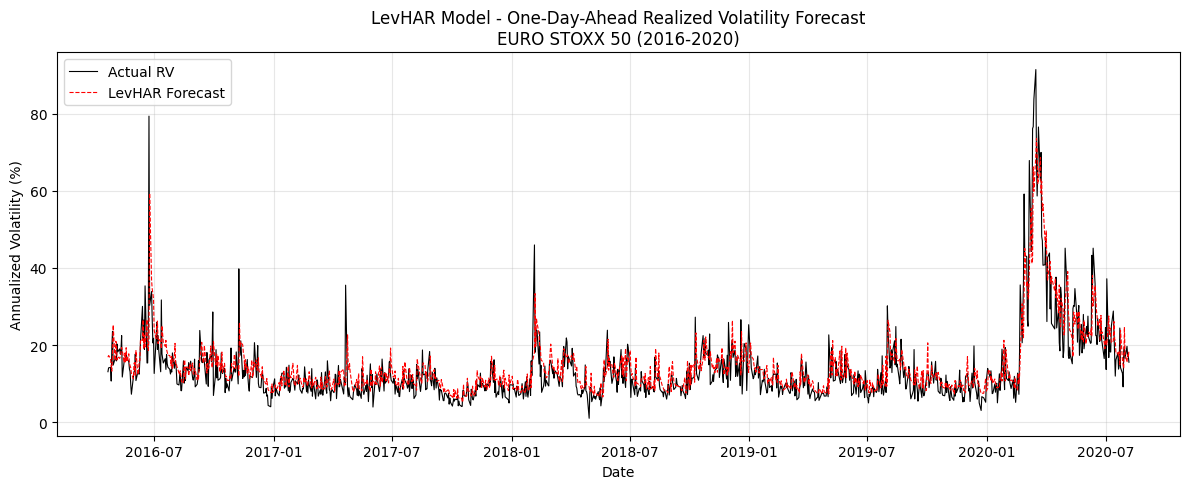


Summary of forecast errors:
Mean error:  -2.067053e-06
RMSE:        1.497024e-04
MAE:         5.592355e-05


In [7]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_LevHAR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_LevHAR["RV_forecast"] * 252) * 100
}, index=results_LevHAR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="LevHAR Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("LevHAR Model - One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016-2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_LevHAR["RV_actual"] - results_LevHAR["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_LevHAR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")


### 4.2 Forecast Performance Summary


In [8]:
from IPython.display import display

# Summary table of forecast performance
performance = pd.DataFrame({
    "Model": ["LevHAR"],
    "MSE":   [mse_LevHAR],
    "RMSE":  [np.sqrt(mse_LevHAR)],
    "MAE":   [errors.abs().mean()],
    "Mean Error": [errors.mean()],
    "Relative MSE": [1.0]
}).set_index("Model")

styled_performance = (
    performance.style
    .set_caption(
        "Table 3: Out-of-Sample Forecast Performance - LevHAR Model\n"
        f"EURO STOXX 50 Test Period: {dates_test[0].date()} to {dates_test[-1].date()} ({n_test} observations)"
    )
    .format({
        "MSE":         "{:.6e}",
        "RMSE":        "{:.6e}",
        "MAE":         "{:.6e}",
        "Mean Error":  "{:.6e}",
        "Relative MSE": "{:.4f}"
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [
             ("font-size", "12px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding-bottom", "8px"),
             ("color", "black"),
             ("caption-side", "top"),
         ]},
        {"selector": "thead tr th",
         "props": [
             ("background-color", "white"),
             ("color", "black"),
             ("font-size", "11px"),
             ("text-align", "center"),
             ("padding", "6px 10px"),
             ("border-top", "2px solid black"),
             ("border-bottom", "1px solid black"),
             ("font-weight", "bold"),
         ]},
        {"selector": "tbody tr th",
         "props": [
             ("font-size", "11px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding", "4px 10px"),
             ("color", "black"),
             ("background-color", "white"),
             ("border-right", "1px solid black"),
         ]},
        {"selector": "tbody tr td",
         "props": [
             ("font-size", "11px"),
             ("text-align", "right"),
             ("padding", "4px 10px"),
             ("background-color", "white"),
             ("color", "black"),
         ]},
        {"selector": "tbody tr:last-child td, tbody tr:last-child th",
         "props": [("border-bottom", "2px solid black")]},
        {"selector": "table",
         "props": [
             ("border-collapse", "collapse"),
             ("width", "100%"),
         ]},
        {"selector": "td, th",
         "props": [
             ("border-left", "none"),
             ("border-right", "none"),
         ]},
    ])
)

display(styled_performance)


,MSE,RMSE,MAE,Mean Error,Relative MSE
Model,,,,,
LevHAR,2.241081e-08,1.497024e-04,5.592355e-05,-2.067053e-06,1.0000
